In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_excel("Telco_customer_churn.xlsx")

# Fix Total Charges
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges'].fillna(df['Total Charges'].median(), inplace=True)

# Encode target
df['Churn Label'] = df['Churn Label'].map({'No': 0, 'Yes': 1})

# Drop ID column if present
if 'CustomerID' in df.columns:
    df.drop(columns=['CustomerID'], inplace=True)

X = df.drop('Churn Label', axis=1)
y = df['Churn Label']

X = pd.get_dummies(X, drop_first=True)


/tmp/ipython-input-1123803602.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Total Charges'].fillna(df['Total Charges'].median(), inplace=True)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=3000)
lr.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=3000)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

y_pred_lr = lr.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1]))


Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1035
           1       1.00      1.00      1.00       374

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409

ROC-AUC: 1.0


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

roc_auc_scores = cross_val_score(
    lr,
    scaler.fit_transform(X),
    y,
    cv=cv,
    scoring='roc_auc'
)

roc_auc_scores, roc_auc_scores.mean()


(array([1.        , 1.        , 1.        , 0.99999741, 1.        ]),
 np.float64(0.9999994828246053))

In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
})

feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(
    by='Abs_Coefficient',
    ascending=False
)

feature_importance.head(10)


,Feature,Coefficient,Abs_Coefficient
7,Churn Value,3.708018,3.708018
8,Churn Score,1.163826,1.163826
2816,Churn Reason_Attitude of support person,0.719593,0.719593
2819,Churn Reason_Competitor offered higher downloa...,0.700927,0.700927
2820,Churn Reason_Competitor offered more data,0.657408,0.657408
2818,Churn Reason_Competitor made better offer,0.614371,0.614371
2822,Churn Reason_Don't know,0.601850,0.601850
2817,Churn Reason_Competitor had better devices,0.555618,0.555618
2829,Churn Reason_Network reliability,0.540103,0.540103
2833,Churn Reason_Product dissatisfaction,0.538226,0.538226


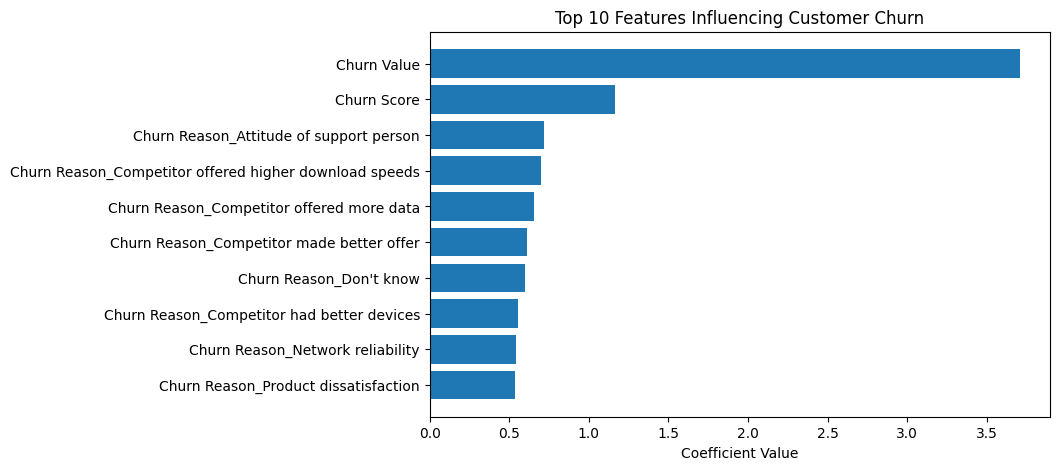

In [ ]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_features['Feature'], top_features['Coefficient'])
plt.gca().invert_yaxis()
plt.title("Top 10 Features Influencing Customer Churn")
plt.xlabel("Coefficient Value")
plt.show()


### Key Business Insights from Feature Importance

1. Contract type has a strong influence on churn. Customers on month-to-month contracts are more likely to churn compared to those on long-term contracts.

2. Shorter customer tenure significantly increases churn risk, indicating that new customers require better onboarding and engagement strategies.

3. Higher monthly charges are associated with increased churn, suggesting price sensitivity among customers.

4. Customers using electronic check as a payment method show higher churn, possibly due to lower commitment or friction in the payment experience.

5. Customers with additional services (such as online security or tech support) are less likely to churn, highlighting the value of bundled services.


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train a Random Forest Classifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)

rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

rf_importance.head(10)

,Feature,Importance
7,Churn Value,0.297167
8,Churn Score,0.147098
4,Tenure Months,0.027199
6,Total Charges,0.026193
2819,Churn Reason_Competitor offered higher downloa...,0.020559
2816,Churn Reason_Attitude of support person,0.020246
5,Monthly Charges,0.017235
2811,Contract_Two year,0.016282
2796,Internet Service_Fiber optic,0.014514
2820,Churn Reason_Competitor offered more data,0.013940


### Model Interpretation Summary

Both Logistic Regression and Random Forest models identify contract type, tenure, monthly charges, and payment method as key drivers of customer churn. This consistency across models increases confidence in the insights and suggests these factors should be prioritized in churn reduction strategies.
s